# 🩺 Lab 4 — Implementation of CNN Architecture
## Skin Lesion Classification using Custom CNN

---

### 📋 Lab Overview

| Field | Details |
|---|---|
| **Lab Name** | Implementation of CNN Architecture |
| **Dataset** | Synthetic Dermoscopy-Style Skin Lesion Images (3 classes) |
| **Domain** | Medical Image Classification |
| **Tools Used** | TensorFlow, Keras, NumPy, Matplotlib, Seaborn, Scikit-learn |

---

### 🎯 Problem Statement

> **Can a Convolutional Neural Network accurately classify skin lesion images into Benign, Malignant, or Seborrheic Keratosis categories?**
>
> Early detection of malignant skin lesions can be life-saving. Automating this process through deep learning reduces reliance on specialist dermoscopy expertise. In this lab, we design, train, and evaluate a custom CNN architecture on synthetic skin lesion-style images generated with identifiable class-specific visual patterns.

### 🎓 Learning Objectives
- Understand convolution, pooling, and fully connected layers
- Build a multi-layer CNN from scratch using Keras
- Apply data augmentation to improve generalization
- Evaluate performance using accuracy, confusion matrix, and classification report
- Visualize feature maps from intermediate CNN layers

---
## 📦 Section 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')
print(f'   TensorFlow: {tf.__version__}')

✅ Libraries loaded!
   TensorFlow: 2.19.0


---
## 🖼️ Section 2: Synthetic Dataset Generation

We generate **1500 synthetic 64×64 RGB images** across 3 skin lesion classes with distinct visual patterns:

| Class | Label | Visual Pattern |
|---|---|---|
| Benign | 0 | Uniform texture with smooth circular patterns |
| Malignant | 1 | Irregular dark blotches + noise (asymmetry) |
| Seborrheic Keratosis | 2 | Rough warty texture with high-contrast patches |

Generating images...
✅ Dataset: 1500 images | Shape: (64, 64, 3) | Classes: 3


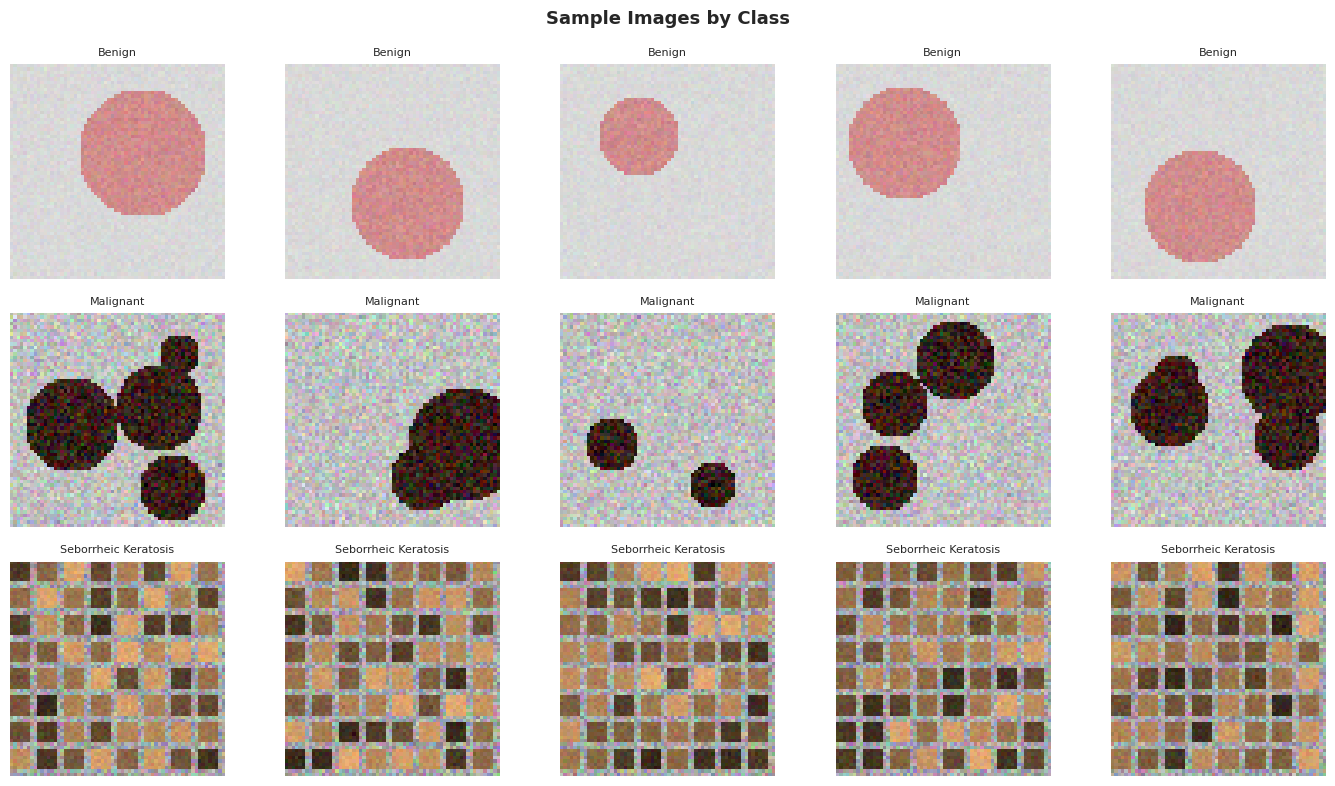

In [2]:
np.random.seed(42)
N_PER_CLASS = 500
IMG_SIZE = 64
N_CLASSES = 3
CLASS_NAMES = ['Benign', 'Malignant', 'Seborrheic Keratosis']

def generate_benign(n):
    """Smooth pinkish circular lesion on light background"""
    imgs = np.ones((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * 0.85
    for i in range(n):
        cx, cy = np.random.randint(20, 44, 2)
        r = np.random.randint(12, 22)
        for x in range(IMG_SIZE):
            for y in range(IMG_SIZE):
                if (x-cx)**2 + (y-cy)**2 < r**2:
                    imgs[i,x,y] = [0.82+np.random.uniform(-0.05,0.05),
                                   0.55+np.random.uniform(-0.05,0.05),
                                   0.55+np.random.uniform(-0.05,0.05)]
        imgs[i] += np.random.normal(0, 0.02, (IMG_SIZE, IMG_SIZE, 3))
    return np.clip(imgs, 0, 1)

def generate_malignant(n):
    """Dark irregular blotches with high noise"""
    imgs = np.ones((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * 0.75
    for i in range(n):
        # Multiple irregular dark patches
        for _ in range(np.random.randint(2, 5)):
            cx, cy = np.random.randint(10, 54, 2)
            r = np.random.randint(6, 18)
            for x in range(max(0,cx-r), min(IMG_SIZE,cx+r)):
                for y in range(max(0,cy-r), min(IMG_SIZE,cy+r)):
                    if (x-cx)**2 + (y-cy)**2 < r**2:
                        imgs[i,x,y] = [np.random.uniform(0.1, 0.35),
                                       np.random.uniform(0.05, 0.2),
                                       np.random.uniform(0.05, 0.15)]
        imgs[i] += np.random.normal(0, 0.08, (IMG_SIZE, IMG_SIZE, 3))
    return np.clip(imgs, 0, 1)

def generate_seb_keratosis(n):
    """High-contrast rough warty texture"""
    imgs = np.random.uniform(0.5, 0.8, (n, IMG_SIZE, IMG_SIZE, 3)).astype(np.float32)
    for i in range(n):
        # Grid-like warty pattern
        for x in range(0, IMG_SIZE, 8):
            for y in range(0, IMG_SIZE, 8):
                patch_color = np.random.uniform(0.2, 0.9)
                imgs[i, x:x+6, y:y+6, 0] = patch_color
                imgs[i, x:x+6, y:y+6, 1] = patch_color * 0.75
                imgs[i, x:x+6, y:y+6, 2] = patch_color * 0.5
        imgs[i] += np.random.normal(0, 0.04, (IMG_SIZE, IMG_SIZE, 3))
    return np.clip(imgs, 0, 1)

print('Generating images...')
X_b = generate_benign(N_PER_CLASS)
X_m = generate_malignant(N_PER_CLASS)
X_s = generate_seb_keratosis(N_PER_CLASS)

X = np.concatenate([X_b, X_m, X_s], axis=0)
y = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS + [2]*N_PER_CLASS)

print(f'✅ Dataset: {X.shape[0]} images | Shape: {X.shape[1:]} | Classes: {N_CLASSES}')

# Visualize samples
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for cls in range(3):
    cls_indices = np.where(y == cls)[0]
    for j in range(5):
        axes[cls, j].imshow(X[cls_indices[j]])
        axes[cls, j].set_title(CLASS_NAMES[cls], fontsize=8)
        axes[cls, j].axis('off')
plt.suptitle('Sample Images by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Section 3: Data Preprocessing & Augmentation

Train : 1050 | Val: 225 | Test: 225


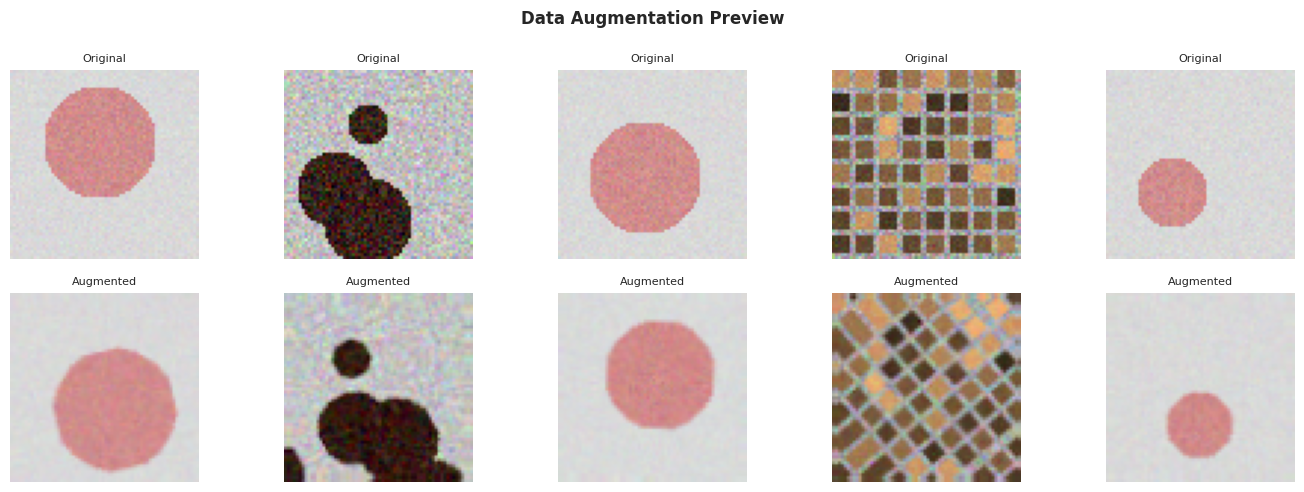

In [3]:
# Train/Val/Test split
y_cat = to_categorical(y, N_CLASSES)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.3, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f'Train : {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Data Augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# Preview augmented images
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i in range(5):
    original = X_train[i]
    augmented = data_augmentation(tf.expand_dims(original, 0))[0].numpy()
    axes[0, i].imshow(original);  axes[0, i].set_title('Original', fontsize=8);  axes[0, i].axis('off')
    axes[1, i].imshow(augmented); axes[1, i].set_title('Augmented', fontsize=8); axes[1, i].axis('off')
plt.suptitle('Data Augmentation Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧠 Section 4: Build the CNN Architecture

```
Input: 64×64×3
↓ Conv2D(32, 3×3) + BN + ReLU → MaxPool(2×2)
↓ Conv2D(64, 3×3) + BN + ReLU → MaxPool(2×2)
↓ Conv2D(128, 3×3) + BN + ReLU → MaxPool(2×2)
↓ Conv2D(256, 3×3) + BN + ReLU → GlobalAvgPool
↓ Dense(256) + ReLU + Dropout(0.5)
↓ Dense(128) + ReLU + Dropout(0.3)
↓ Dense(3) + Softmax
```

In [4]:
def build_cnn(input_shape=(64, 64, 3), n_classes=3):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='SkinLesion_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "SkinLesion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 489,411 (1.87 MB)

 Trainable params: 488,451 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

---
## 🏋️ Section 5: Train the CNN

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=6, min_lr=1e-7, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Training done! Best epoch: {np.argmin(history.history["val_loss"]) + 1}')

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 566ms/step - accuracy: 0.8476 - loss: 0.4035 - val_accuracy: 0.3822 - val_loss: 1.2637 - learning_rate: 5.0000e-04
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 568ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.3822 - val_loss: 4.8434 - learning_rate: 5.0000e-04
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 529ms/step - accuracy: 1.0000 - loss: 9.6196e-04 - val_accuracy: 0.3822 - val_loss: 5.1845 - learning_rate: 5.0000e-04
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 548ms/step - accuracy: 1.0000 - loss: 5.4122e-04 - val_accuracy: 0.3822 - val_loss: 4.4815 - learning_rate: 5.0000e-04
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 574ms/step - accuracy: 1.0000 - loss: 3.3676e-04 - val_accuracy: 0.3911 - val_loss: 2.8233 - learning_rate: 5.0000e-04
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 528ms/step - accuracy: 1.0000 - loss: 1.7497e-04 - val_accuracy: 0.7422 - val_loss: 1.1028 - learning_rate: 5.0000e-04
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 

---
## 📊 Section 6: Evaluation

Test Accuracy : 100.00%
Test Loss     : 0.0000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step

=== Classification Report ===
                      precision    recall  f1-score   support

              Benign       1.00      1.00      1.00        64
           Malignant       1.00      1.00      1.00        83
Seborrheic Keratosis       1.00      1.00      1.00        78

            accuracy                           1.00       225
           macro avg       1.00      1.00      1.00       225
        weighted avg       1.00      1.00      1.00       225



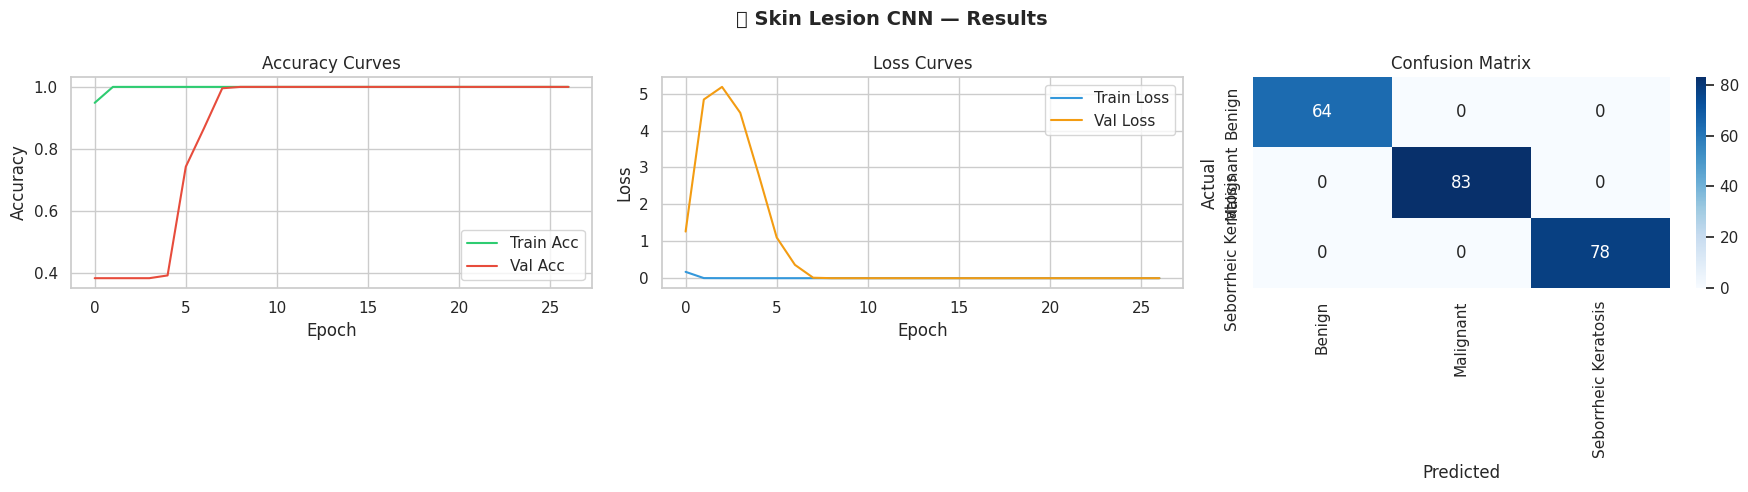

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy curves
axes[0].plot(history.history['accuracy'],     label='Train Acc', color='#2ECC71')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='#E74C3C')
axes[0].set_title('Accuracy Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss curves
axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498DB')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#F39C12')
axes[1].set_title('Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('🩺 Skin Lesion CNN — Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔬 Section 7: Feature Map Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


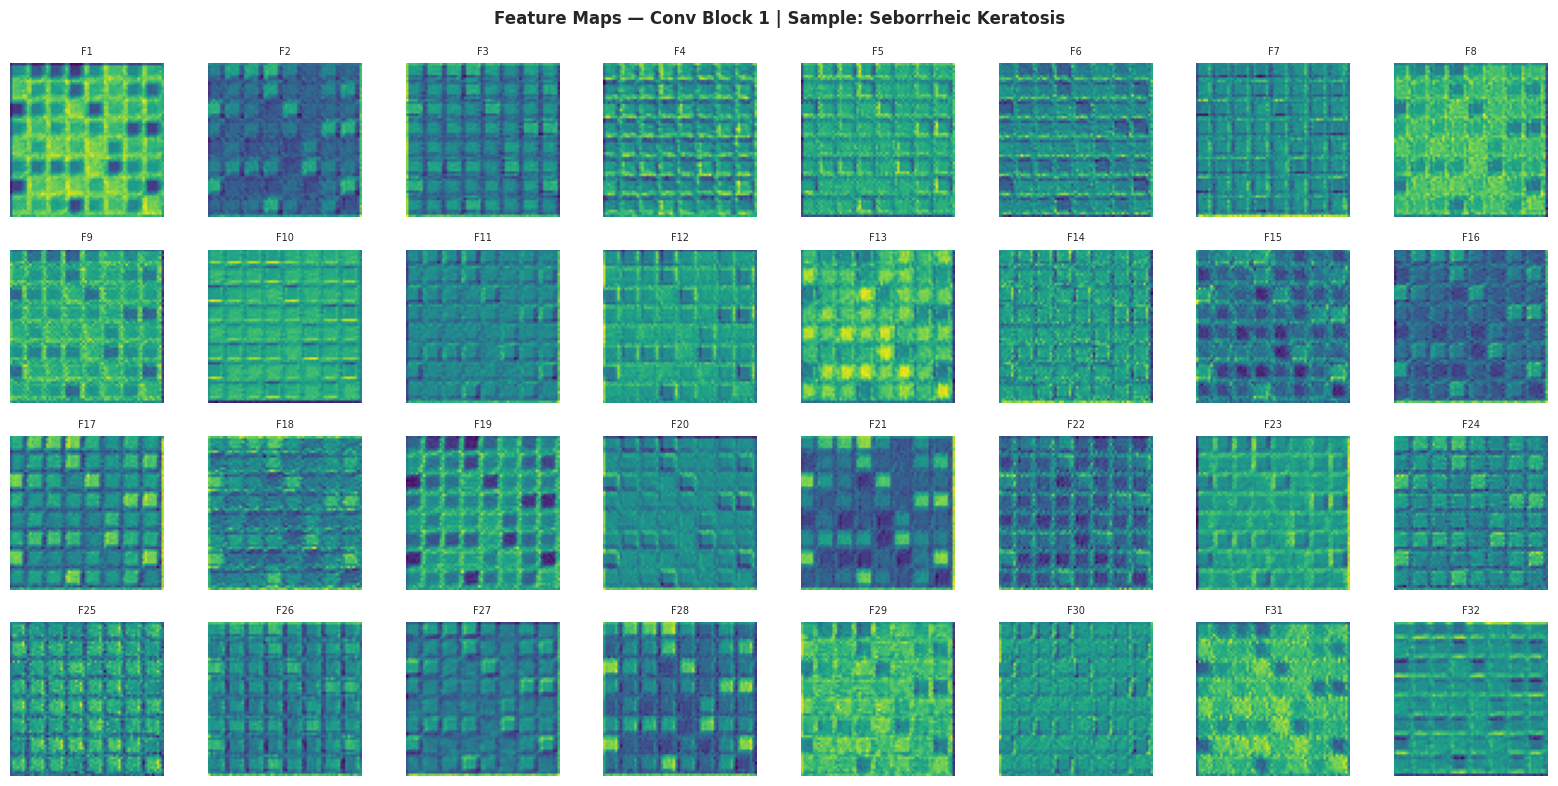


✅ Lab 4 Complete! Final Test Accuracy: 100.00%


In [7]:
# Extract first conv layer feature maps
feature_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[3].output  # First Conv2D output (after augmentation layers)
)

sample_img = np.expand_dims(X_test[0], axis=0)
feature_maps = feature_model.predict(sample_img)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(32):
    ax = axes[i//8, i%8]
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f'F{i+1}', fontsize=7)

plt.suptitle(f'Feature Maps — Conv Block 1 | Sample: {CLASS_NAMES[y_true[0]]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Lab 4 Complete! Final Test Accuracy: {test_acc*100:.2f}%')